Customer Churn Prediction using Machine Learning

In [ ]:
# Install required packages
%pip install numpy pandas matplotlib seaborn scikit-learn imbalanced-learn joblib



  Using cached numpy-2.0.2-cp39-cp39-macosx_14_0_arm64.whl.metadata (60 kB)
  Using cached pandas-2.3.3-cp39-cp39-macosx_11_0_arm64.whl.metadata (91 kB)
  Using cached matplotlib-3.9.4-cp39-cp39-macosx_11_0_arm64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.6.1-cp39-cp39-macosx_12_0_arm64.whl.metadata (31 kB)
  Using cached imbalanced_learn-0.12.4-py3-none-any.whl.metadata (8.3 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.0-cp39-cp39-macosx_11_0_arm64.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.60.1-cp39-cp39-macosx_10_9_universal2.whl.metadata (112 kB)
  Using cached kiwisolver-1.4.7-cp39-cp39-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached pillow-11.3.0-cp39-

Customer Churn Prediction

In [6]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report, 
                             roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [7]:
# Load the dataset
df = pd.read_csv('data/churn_data.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset loaded successfully!
Shape: (7043, 21)

First few rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
# Basic information about the dataset
print("="*60)
print("DATASET INFORMATION")
print("="*60)
print(f"\nDataset Shape: {df.shape}")
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

print("\n" + "="*60)
print("COLUMN INFORMATION")
print("="*60)
print(df.info())

print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)
print(df.isnull().sum())

print("\n" + "="*60)
print("STATISTICAL SUMMARY")
print("="*60)
df.describe()

DATASET INFORMATION

Dataset Shape: (7043, 21)
Number of Rows: 7043
Number of Columns: 21

COLUMN INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Target Variable: Churn

CLASS DISTRIBUTION
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentage Distribution:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


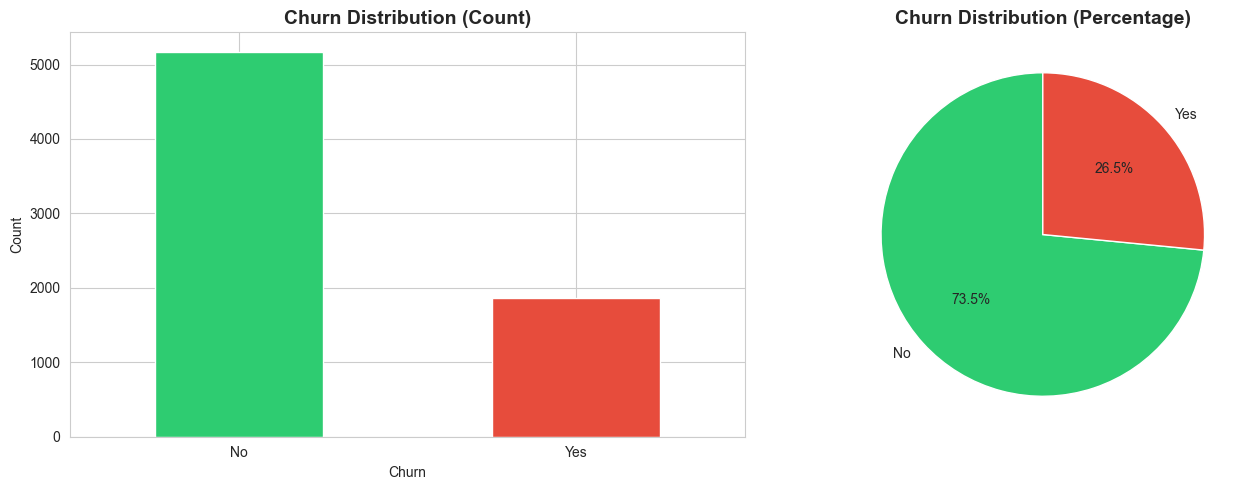

In [10]:
# Check churn distribution
if 'Churn' in df.columns:
    target_col = 'Churn'
elif 'Purchased' in df.columns:
    target_col = 'Purchased'
else:
    target_col = df.columns[-1]

print(f"Target Variable: {target_col}")
print("\n" + "="*60)
print("CLASS DISTRIBUTION")
print("="*60)
print(df[target_col].value_counts())
print(f"\nPercentage Distribution:")
print(df[target_col].value_counts(normalize=True) * 100)

# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
df[target_col].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title(f'{target_col} Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel(target_col)
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Pie chart
df[target_col].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                    colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title(f'{target_col} Distribution (Percentage)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [11]:
# Handle missing values
print("Handling missing values...")
initial_rows = len(df)

# Convert TotalCharges to numeric if exists
if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop rows with missing values
df = df.dropna()

dropped_rows = initial_rows - len(df)
print(f"Dropped {dropped_rows} rows with missing values")
print(f"Remaining rows: {len(df)}")

# Feature Engineering
print("\nPerforming feature engineering...")

if 'tenure' in df.columns:
    # Create tenure groups
    df['tenure_group'] = pd.cut(df['tenure'], 
                                bins=[0, 12, 24, 48, 72],
                                labels=['0-12', '12-24', '24-48', '48+'])

if 'MonthlyCharges' in df.columns and 'TotalCharges' in df.columns:
    # Calculate charges ratio
    df['charges_ratio'] = df['MonthlyCharges'] / (df['TotalCharges'] + 1)

print("Feature engineering completed!")

Handling missing values...
Dropped 11 rows with missing values
Remaining rows: 7032

Performing feature engineering...
Feature engineering completed!


In [12]:
# Encoding categorical variables
print("Encoding categorical variables...")

# Binary encoding for Yes/No columns
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map({'Yes': 1, 'No': 0})
        print(f"✓ Encoded {col}")

# Label encoding for other categorical columns
label_encoders = {}
categorical_cols = ['gender', 'MultipleLines', 'InternetService',
                   'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                   'TechSupport', 'StreamingTV', 'StreamingMovies',
                   'Contract', 'PaymentMethod', 'tenure_group']

for col in categorical_cols:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le
        print(f"✓ Encoded {col}")

# Drop customerID if exists
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)
    print("✓ Dropped customerID")

print(f"\nEncoded {len(categorical_cols)} categorical columns")
print("\n✅ Data preprocessing completed!")

Encoding categorical variables...
✓ Encoded Partner
✓ Encoded Dependents
✓ Encoded PhoneService
✓ Encoded PaperlessBilling
✓ Encoded Churn
✓ Encoded gender
✓ Encoded MultipleLines
✓ Encoded InternetService
✓ Encoded OnlineSecurity
✓ Encoded OnlineBackup
✓ Encoded DeviceProtection
✓ Encoded TechSupport
✓ Encoded StreamingTV
✓ Encoded StreamingMovies
✓ Encoded Contract
✓ Encoded PaymentMethod
✓ Encoded tenure_group
✓ Dropped customerID

Encoded 12 categorical columns

✅ Data preprocessing completed!


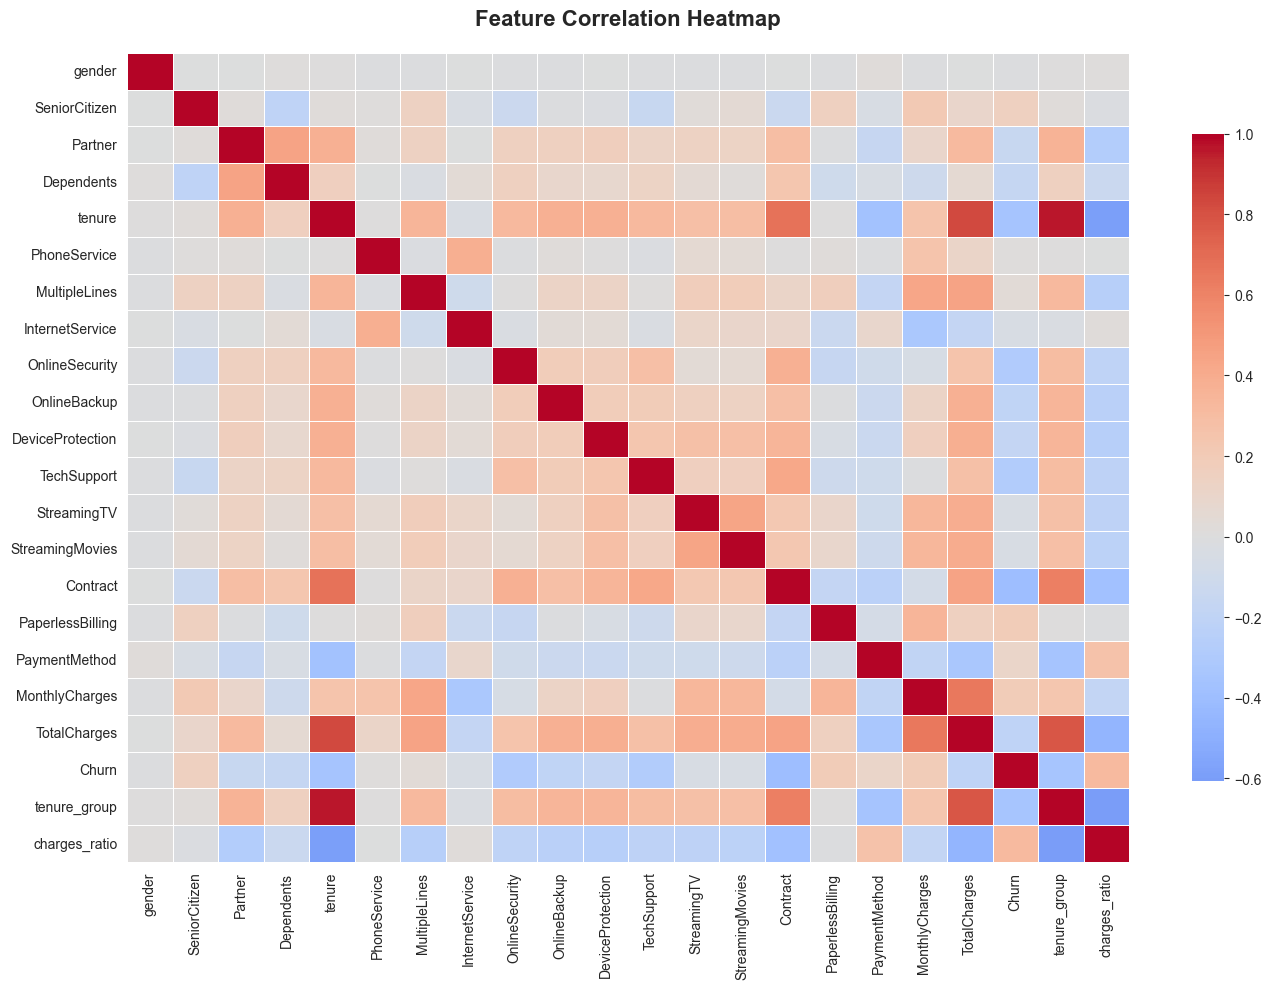


TOP CORRELATIONS WITH Churn
charges_ratio       0.321710
MonthlyCharges      0.192858
PaperlessBilling    0.191454
SeniorCitizen       0.150541
PaymentMethod       0.107852
MultipleLines       0.038043
PhoneService        0.011691
gender             -0.008545
StreamingTV        -0.036303
StreamingMovies    -0.038802
Name: Churn, dtype: float64


In [13]:
# Correlation analysis
plt.figure(figsize=(14, 10))
correlation_matrix = df.corr()

sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, 
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Top correlations with target variable
print("\n" + "="*60)
print(f"TOP CORRELATIONS WITH {target_col}")
print("="*60)
target_corr = correlation_matrix[target_col].sort_values(ascending=False)
print(target_corr[1:11])  # Top 10 excluding itself

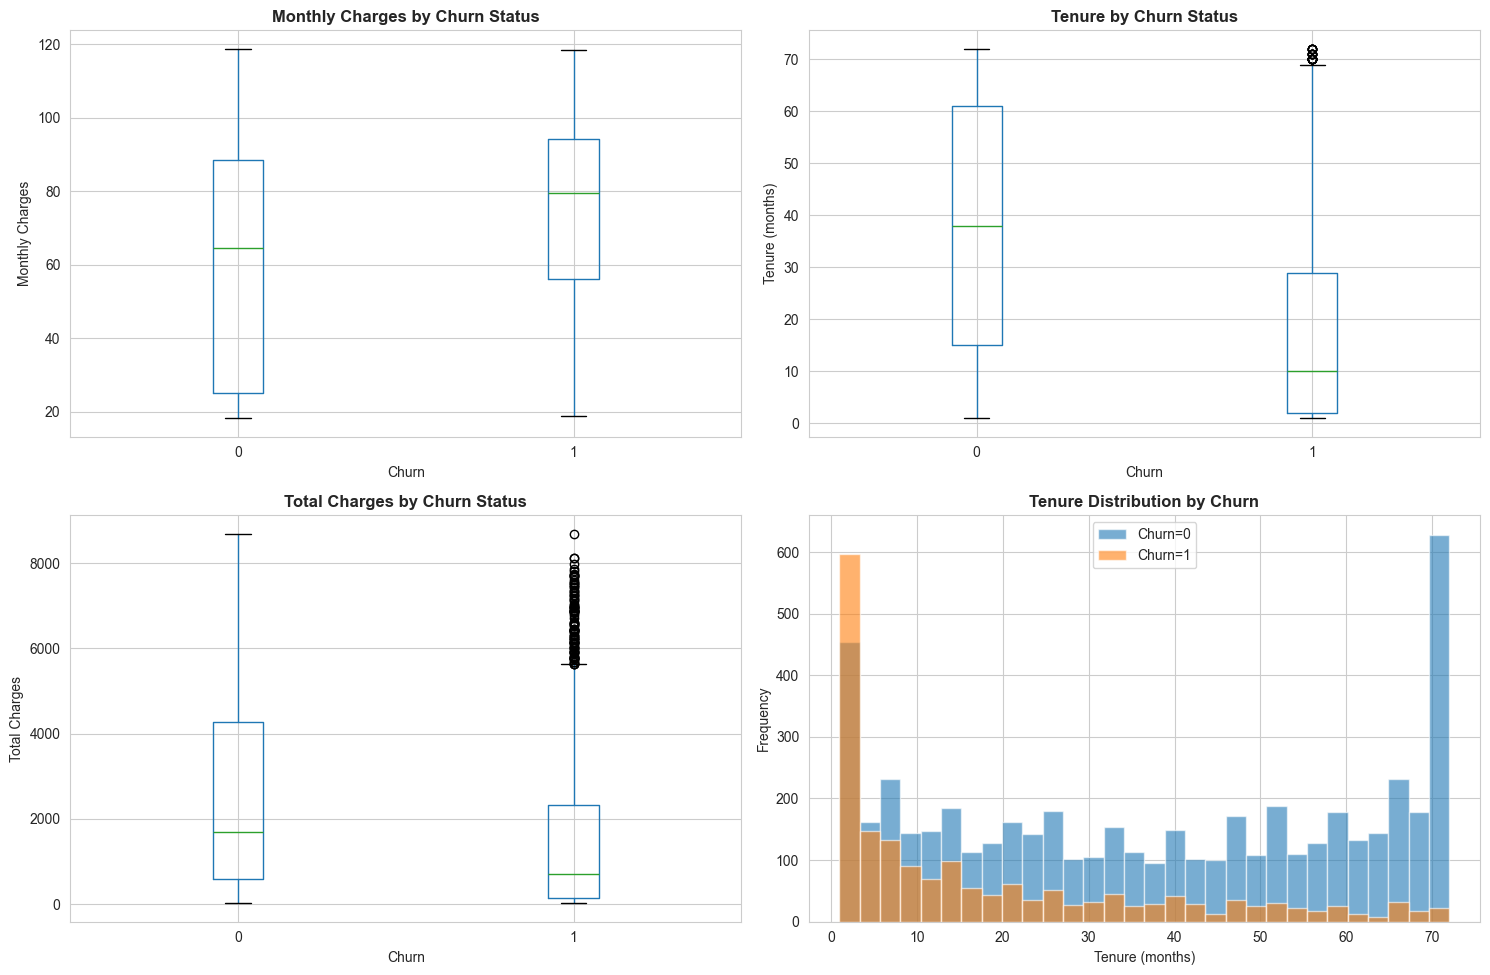

In [14]:
# Feature importance using numerical columns
if 'MonthlyCharges' in df.columns and 'tenure' in df.columns:
    # Plot key features vs churn
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Monthly Charges vs Churn
    df.boxplot(column='MonthlyCharges', by=target_col, ax=axes[0, 0])
    axes[0, 0].set_title('Monthly Charges by Churn Status', fontweight='bold')
    axes[0, 0].set_xlabel('Churn')
    axes[0, 0].set_ylabel('Monthly Charges')
    
    # Tenure vs Churn
    df.boxplot(column='tenure', by=target_col, ax=axes[0, 1])
    axes[0, 1].set_title('Tenure by Churn Status', fontweight='bold')
    axes[0, 1].set_xlabel('Churn')
    axes[0, 1].set_ylabel('Tenure (months)')
    
    # Total Charges vs Churn
    if 'TotalCharges' in df.columns:
        df.boxplot(column='TotalCharges', by=target_col, ax=axes[1, 0])
        axes[1, 0].set_title('Total Charges by Churn Status', fontweight='bold')
        axes[1, 0].set_xlabel('Churn')
        axes[1, 0].set_ylabel('Total Charges')
    
    # Distribution of tenure
    for churn_val in df[target_col].unique():
        df[df[target_col] == churn_val]['tenure'].hist(ax=axes[1, 1], 
                                                         alpha=0.6, 
                                                         label=f'Churn={churn_val}',
                                                         bins=30)
    axes[1, 1].set_title('Tenure Distribution by Churn', fontweight='bold')
    axes[1, 1].set_xlabel('Tenure (months)')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].legend()
    
    plt.suptitle('')  # Remove default title
    plt.tight_layout()
    plt.show()

In [15]:
# Separate features and target
X = df.drop(target_col, axis=1)
y = df[target_col]

print("="*60)
print("DATA PREPARATION FOR MODELING")
print("="*60)
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures: {list(X.columns)}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Feature scaling completed!")

DATA PREPARATION FOR MODELING
Features shape: (7032, 21)
Target shape: (7032,)

Features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'tenure_group', 'charges_ratio']

Training set size: (5625, 21)
Test set size: (1407, 21)

✅ Feature scaling completed!


In [16]:
# Apply SMOTE to balance classes
print("="*60)
print("HANDLING CLASS IMBALANCE")
print("="*60)
print(f"\nBefore SMOTE:")
print(y_train.value_counts())
print(f"Class distribution: {y_train.value_counts(normalize=True).values}")

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"\nAfter SMOTE:")
print(pd.Series(y_train_balanced).value_counts())
print(f"Class distribution: {pd.Series(y_train_balanced).value_counts(normalize=True).values}")

print("\n✅ Class balancing completed!")

HANDLING CLASS IMBALANCE

Before SMOTE:
Churn
0    4130
1    1495
Name: count, dtype: int64
Class distribution: [0.73422222 0.26577778]

After SMOTE:
Churn
0    4130
1    4130
Name: count, dtype: int64
Class distribution: [0.5 0.5]

✅ Class balancing completed!


In [17]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, 
                                           random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, 
                                                    learning_rate=0.1,
                                                    max_depth=5, 
                                                    random_state=42)
}

# Train models
print("="*60)
print("TRAINING MODELS")
print("="*60)

trained_models = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_balanced, y_train_balanced)
    trained_models[name] = model
    print(f"✅ {name} training completed!")

print("\n✅ All models trained successfully!")

TRAINING MODELS

Training Logistic Regression...
✅ Logistic Regression training completed!

Training Random Forest...
✅ Random Forest training completed!

Training Gradient Boosting...
✅ Gradient Boosting training completed!

✅ All models trained successfully!


In [18]:
# Evaluate all models
results = {}

print("="*60)
print("MODEL EVALUATION RESULTS")
print("="*60)

for name, model in trained_models.items():
    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"\n{name}:")
    print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  ROC-AUC:   {roc_auc:.4f}")

# Find best model
best_model_name = max(results, key=lambda x: results[x]['accuracy'])
print(f"\n{'='*60}")
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"   Accuracy: {results[best_model_name]['accuracy']*100:.2f}%")
print(f"{'='*60}")

MODEL EVALUATION RESULTS

Logistic Regression:
  Accuracy:  0.7342 (73.42%)
  Precision: 0.5000
  Recall:    0.7968
  F1-Score:  0.6144
  ROC-AUC:   0.8380

Random Forest:
  Accuracy:  0.7697 (76.97%)
  Precision: 0.5539
  Recall:    0.6872
  F1-Score:  0.6134
  ROC-AUC:   0.8305

Gradient Boosting:
  Accuracy:  0.7747 (77.47%)
  Precision: 0.5690
  Recall:    0.6283
  F1-Score:  0.5972
  ROC-AUC:   0.8327

🏆 BEST MODEL: Gradient Boosting
   Accuracy: 77.47%


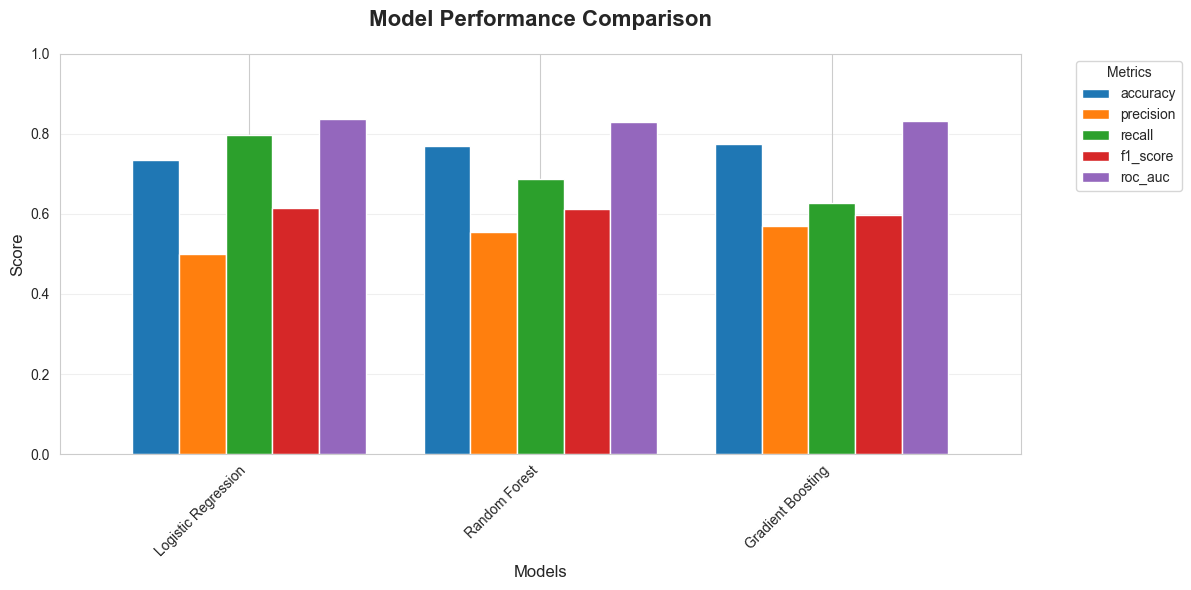


MODEL PERFORMANCE SUMMARY
                     accuracy precision    recall  f1_score   roc_auc
Logistic Regression  0.734186       0.5  0.796791  0.614433  0.837997
Random Forest        0.769723  0.553879  0.687166  0.613365  0.830478
Gradient Boosting    0.774698  0.569007  0.628342  0.597205  0.832707


In [19]:
# Compare models visually
metrics_df = pd.DataFrame(results).T[['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']]

fig, ax = plt.subplots(figsize=(12, 6))
metrics_df.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Model Performance Comparison', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Models', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

# Display as table
print("\n" + "="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)
print(metrics_df.round(4))

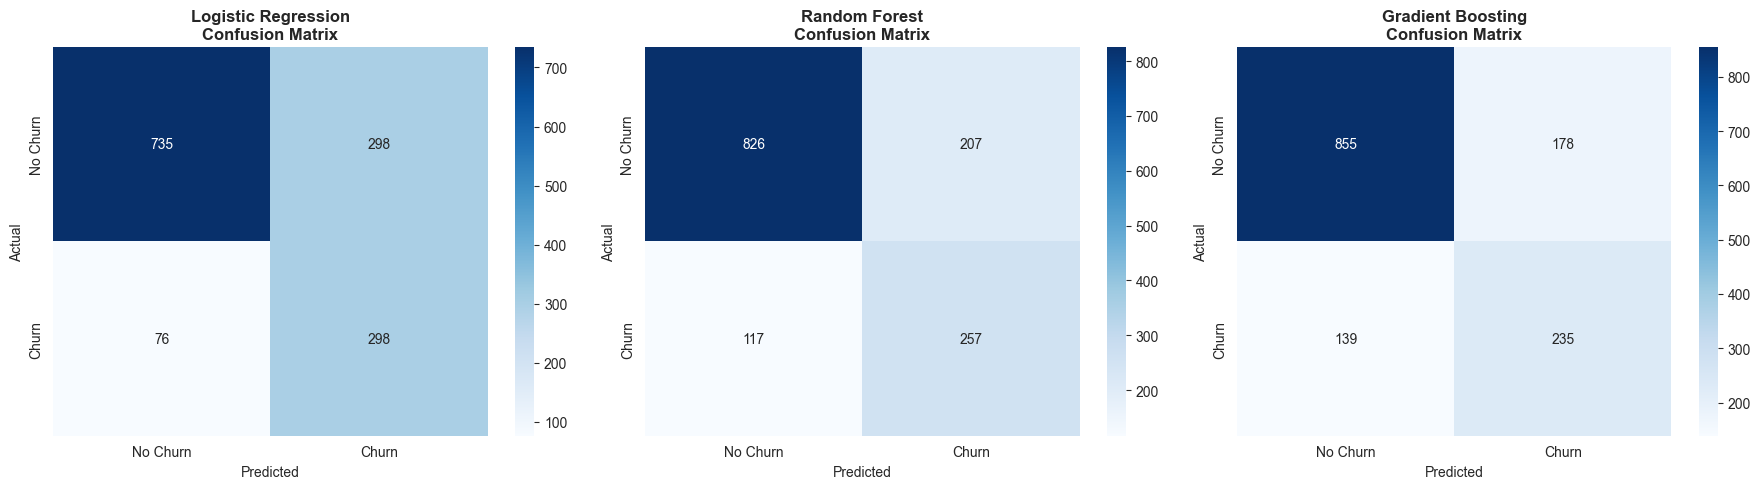

In [20]:
# Plot confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(trained_models.items()):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    axes[idx].set_title(f'{name}\nConfusion Matrix', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Actual', fontsize=10)
    axes[idx].set_xlabel('Predicted', fontsize=10)

plt.tight_layout()
plt.show()

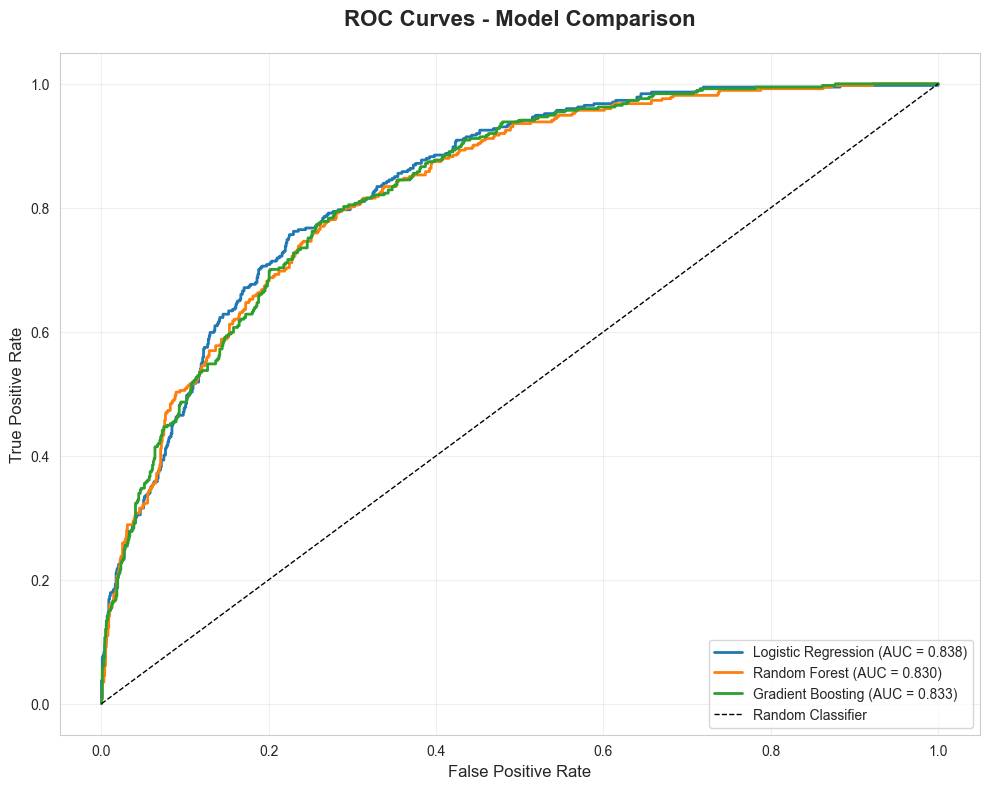

In [21]:
# Plot ROC curves
plt.figure(figsize=(10, 8))

for name in trained_models.keys():
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_pred_proba'])
    auc_score = results[name]['roc_auc']
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=16, fontweight='bold', pad=20)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

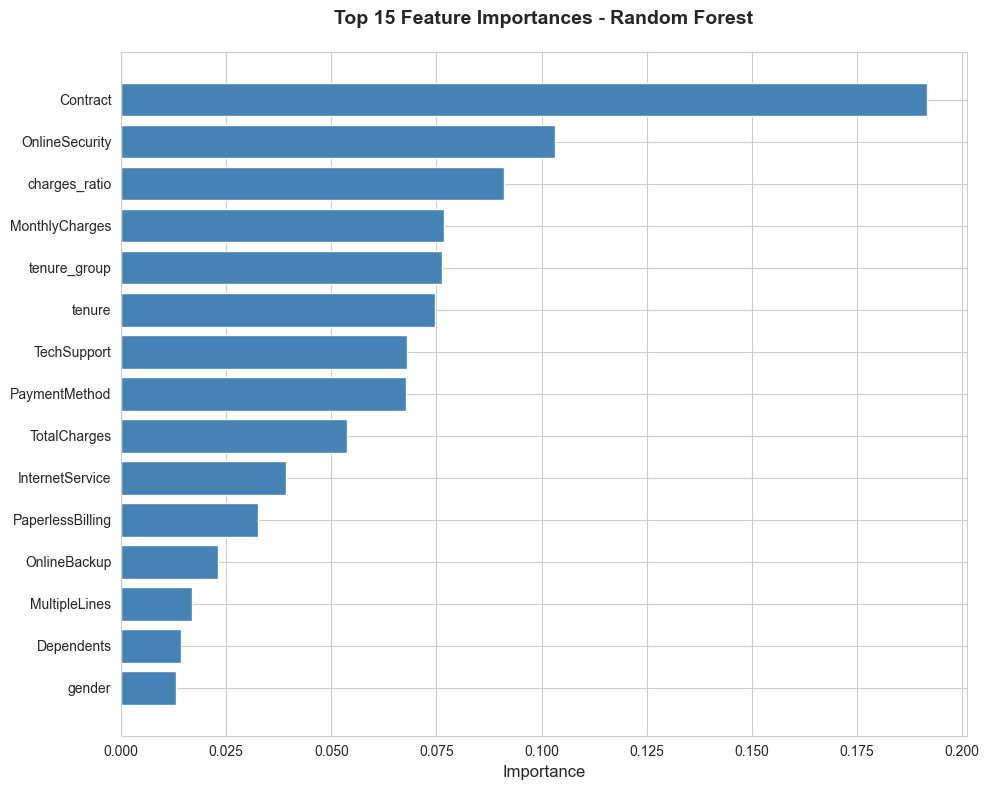


TOP 10 MOST IMPORTANT FEATURES
        feature  importance
       Contract    0.191541
 OnlineSecurity    0.103294
  charges_ratio    0.090957
 MonthlyCharges    0.076743
   tenure_group    0.076219
         tenure    0.074757
    TechSupport    0.068077
  PaymentMethod    0.067831
   TotalCharges    0.053813
InternetService    0.039156


In [22]:
# Feature importance for Random Forest
if 'Random Forest' in trained_models:
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': trained_models['Random Forest'].feature_importances_
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(10, 8))
    top_15 = feature_importance.head(15)
    plt.barh(range(len(top_15)), top_15['importance'].values, color='steelblue')
    plt.yticks(range(len(top_15)), top_15['feature'].values)
    plt.xlabel('Importance', fontsize=12)
    plt.title('Top 15 Feature Importances - Random Forest', 
              fontsize=14, fontweight='bold', pad=20)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*60)
    print("TOP 10 MOST IMPORTANT FEATURES")
    print("="*60)
    print(feature_importance.head(10).to_string(index=False))

In [23]:
# Detailed classification report for best model
print("="*60)
print(f"DETAILED CLASSIFICATION REPORT - {best_model_name}")
print("="*60)
print(classification_report(y_test, results[best_model_name]['y_pred'],
                          target_names=['No Churn', 'Churn']))

DETAILED CLASSIFICATION REPORT - Gradient Boosting
              precision    recall  f1-score   support

    No Churn       0.86      0.83      0.84      1033
       Churn       0.57      0.63      0.60       374

    accuracy                           0.77      1407
   macro avg       0.71      0.73      0.72      1407
weighted avg       0.78      0.77      0.78      1407



In [24]:
# Save the best model and scaler
import os

os.makedirs('models', exist_ok=True)

# Save model
best_model = trained_models[best_model_name]
joblib.dump(best_model, 'models/churn_model.pkl')
print(f"✅ Best model ({best_model_name}) saved to: models/churn_model.pkl")

# Save scaler
joblib.dump(scaler, 'models/scaler.pkl')
print(f"✅ Scaler saved to: models/scaler.pkl")

# Save feature names
joblib.dump(list(X.columns), 'models/feature_names.pkl')
print(f"✅ Feature names saved to: models/feature_names.pkl")

print("\n" + "="*60)
print("MODEL ARTIFACTS SAVED SUCCESSFULLY!")
print("="*60)

✅ Best model (Gradient Boosting) saved to: models/churn_model.pkl
✅ Scaler saved to: models/scaler.pkl
✅ Feature names saved to: models/feature_names.pkl

MODEL ARTIFACTS SAVED SUCCESSFULLY!


In [25]:
# Function to make predictions on new data
def predict_churn(model, scaler, customer_data, feature_names):
    """
    Predict churn for a customer
    
    Args:
        model: Trained model
        scaler: Fitted scaler
        customer_data: Dictionary with customer features
        feature_names: List of feature names
    
    Returns:
        Dictionary with prediction results
    """
    # Create DataFrame
    df_pred = pd.DataFrame([customer_data])[feature_names]
    
    # Scale features
    df_scaled = scaler.transform(df_pred)
    
    # Predict
    prediction = model.predict(df_scaled)[0]
    probability = model.predict_proba(df_scaled)[0]
    
    return {
        'will_churn': 'Yes' if prediction == 1 else 'No',
        'churn_probability': round(probability[1] * 100, 2),
        'retention_probability': round(probability[0] * 100, 2),
        'risk_level': 'High' if probability[1] > 0.6 else 'Medium' if probability[1] > 0.3 else 'Low'
    }

# Test with sample customers
print("="*60)
print("SAMPLE PREDICTIONS")
print("="*60)

# Sample customer 1: High risk
sample_1 = {
    col: X_test.iloc[0][col] for col in X.columns
}

result_1 = predict_churn(best_model, scaler, sample_1, X.columns)

print("\nCustomer 1:")
print(f"  Will Churn: {result_1['will_churn']}")
print(f"  Churn Probability: {result_1['churn_probability']}%")
print(f"  Risk Level: {result_1['risk_level']}")

# Sample customer 2: Low risk
sample_2 = {
    col: X_test.iloc[50][col] for col in X.columns
}

result_2 = predict_churn(best_model, scaler, sample_2, X.columns)

print("\nCustomer 2:")
print(f"  Will Churn: {result_2['will_churn']}")
print(f"  Churn Probability: {result_2['churn_probability']}%")
print(f"  Risk Level: {result_2['risk_level']}")

SAMPLE PREDICTIONS

Customer 1:
  Will Churn: No
  Churn Probability: 1.85%
  Risk Level: Low

Customer 2:
  Will Churn: Yes
  Churn Probability: 68.38%
  Risk Level: High


In [26]:
# Generate business insights
print("="*60)
print("📊 BUSINESS INSIGHTS & RECOMMENDATIONS")
print("="*60)

print("\n1. KEY FINDINGS:")
print("   " + "-"*56)

if 'Contract' in X.columns:
    contract_churn = df.groupby('Contract')[target_col].mean()
    print(f"   • Month-to-month contracts have highest churn risk")

if 'tenure' in df.columns:
    avg_tenure_churn = df[df[target_col]==1]['tenure'].mean()
    avg_tenure_stay = df[df[target_col]==0]['tenure'].mean()
    print(f"   • Average tenure of churners: {avg_tenure_churn:.1f} months")
    print(f"   • Average tenure of non-churners: {avg_tenure_stay:.1f} months")

print("\n2. RETENTION STRATEGIES:")
print("   " + "-"*56)
print("   • Focus on customers in first 12 months (high risk period)")
print("   • Offer incentives for longer contract commitments")
print("   • Provide proactive support to high-risk customers")
print("   • Implement loyalty rewards program")

print("\n3. MODEL PERFORMANCE:")
print("   " + "-"*56)
print(f"   • Best Model: {best_model_name}")
print(f"   • Accuracy: {results[best_model_name]['accuracy']*100:.2f}%")
print(f"   • Can identify {results[best_model_name]['recall']*100:.1f}% of potential churners")
print(f"   • ROC-AUC Score: {results[best_model_name]['roc_auc']:.3f}")

print("\n" + "="*60)
print("✅ ANALYSIS COMPLETE!")
print("="*60)

📊 BUSINESS INSIGHTS & RECOMMENDATIONS

1. KEY FINDINGS:
   --------------------------------------------------------
   • Month-to-month contracts have highest churn risk
   • Average tenure of churners: 18.0 months
   • Average tenure of non-churners: 37.7 months

2. RETENTION STRATEGIES:
   --------------------------------------------------------
   • Focus on customers in first 12 months (high risk period)
   • Offer incentives for longer contract commitments
   • Provide proactive support to high-risk customers
   • Implement loyalty rewards program

3. MODEL PERFORMANCE:
   --------------------------------------------------------
   • Best Model: Gradient Boosting
   • Accuracy: 77.47%
   • Can identify 62.8% of potential churners
   • ROC-AUC Score: 0.833

✅ ANALYSIS COMPLETE!
